In [1]:
# ============================================================
# Notebook 05: Model Evaluation & Threshold Optimization
# AI Financial Risk Intelligence Platform
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

PROJECT_ROOT = Path(r"C:\Users\user\machine-learning-models-practical\AIML Engineer Training Series\AI_Financial_Risk_Intelligence_Platform")

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "german.data"

column_names = [
    "status", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment_duration", "installment_rate", "personal_status_sex",
    "other_debtors", "present_residence", "property", "age",
    "other_installment_plans", "housing", "existing_credits", "job",
    "people_liable", "telephone", "foreign_worker", "target"
]

df = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
    names=column_names
)

df["target"] = df["target"].map({1: 0, 2: 1})

# ------------------------------------------------------------
# Features and Target
# ------------------------------------------------------------

X = df.drop(columns="target")
y = df["target"]

# ------------------------------------------------------------
# Train/Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Feature Types
# ------------------------------------------------------------

categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

# ------------------------------------------------------------
# Preprocessor
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# ------------------------------------------------------------
# Logistic Regression Pipeline
# ------------------------------------------------------------

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

pipeline.fit(X_train, y_train)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("Pipeline trained successfully")
print(f"ROC-AUC: {auc:.4f}")

Pipeline trained successfully
ROC-AUC: 0.8040


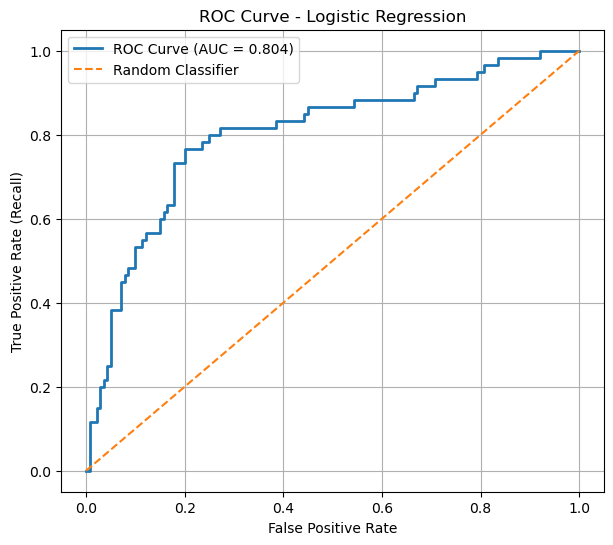

In [2]:
# ============================================================
# ROC Curve
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)

plt.show()

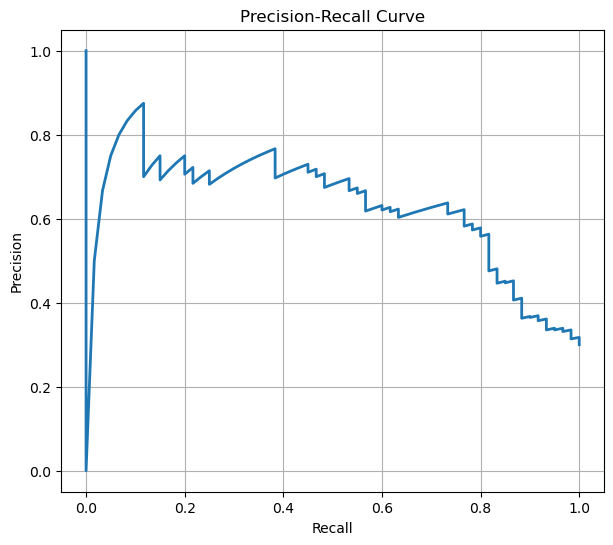

In [3]:
# ============================================================
# Precision-Recall Curve
# ============================================================

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(recall, precision, linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)

plt.show()

In [4]:
# ============================================================
# Threshold Optimization
# ============================================================

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    pred = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

display(results_df)

best_row = results_df.loc[results_df["F1"].idxmax()]

print("\nBest Threshold:")
print(best_row)

,Threshold,Precision,Recall,F1
0,0.10,0.364865,0.900000,0.519231
1,0.15,0.410853,0.883333,0.560847
2,0.20,0.458716,0.833333,0.591716
3,0.25,0.505155,0.816667,0.624204
4,0.30,0.563218,0.816667,0.666667
5,0.35,0.597403,0.766667,0.671533
6,0.40,0.632353,0.716667,0.671875
7,0.45,0.620690,0.600000,0.610169
8,0.50,0.666667,0.533333,0.592593
9,0.55,0.707317,0.483333,0.574257



Best Threshold:
Threshold    0.400000
Precision    0.632353
Recall       0.716667
F1           0.671875
Name: 6, dtype: float64


## Threshold Optimization

The default classification threshold of **0.50** was compared with multiple probability thresholds.

The best F1 score was obtained at a threshold of **0.40**.

| Metric    | Threshold 0.50 | Threshold 0.40 |
| --------- | -------------- | -------------- |
| Precision | 0.667          | 0.632          |
| Recall    | 0.533          | 0.717          |
| F1 Score  | 0.593          | 0.672          |

Lowering the threshold significantly increased recall, meaning that the model identified a larger proportion of risky borrowers.

From a banking perspective, reducing **false negatives** is often more valuable than maximizing accuracy because approving a high-risk applicant can result in substantial financial losses.

This demonstrates that **decision-threshold optimization can improve business performance without changing the underlying machine learning algorithm**.
